In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor



In [6]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
X = df.drop('math score',axis=1)

In [9]:
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [11]:
y = df['math score']

In [12]:
num_feature = X.select_dtypes(exclude='object').columns
col_feature = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,col_feature),
        ("StandardScaler",numeric_transformer,num_feature)
    ]
)

C:\Users\subha\AppData\Local\Temp\ipykernel_18528\698048474.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_feature = X.select_dtypes(include='object').columns


In [13]:
X = preprocessor.fit_transform(X)

In [14]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [15]:
X.shape

(1000, 19)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

In [18]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,predicted)

    return mae,mse,rmse,r2


In [22]:
from sklearn.ensemble import AdaBoostRegressor
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-neighbors Regressor":KNeighborsRegressor(),
    "Decission Tree Regressor":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=0),
    "AdaBoost Regressor":AdaBoostRegressor()
}
model_list=[]
r2_list=[]

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    model_train_mae,model_train_mse,model_train_rmse,model_train_r2 = evaluate_model(y_train,y_train_pred)

    model_test_mae, model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for Training set")
    print("Root Mean Square Error:{:.4f}".format(model_train_rmse))
    print("Mean Absoloute Error:{:.4f}".format(model_train_mae))
    print("R2_score:{:.4f}".format(model_train_r2))

    print('------------------------------------')

    print("Model Performance for Test set")
    print("Root Mean Square Error:{:.4f}".format(model_test_rmse))
    print("Mean Absoloute Error:{:.4f}".format(model_test_mae))
    print("R2_score:{:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)


Linear Regression
Model Performance for Training set
Root Mean Square Error:5.3231
Mean Absoloute Error:4.2667
R2_score:0.8743
------------------------------------
Model Performance for Test set
Root Mean Square Error:5.3940
Mean Absoloute Error:4.2148
R2_score:0.8804
Lasso
Model Performance for Training set
Root Mean Square Error:6.5938
Mean Absoloute Error:5.2063
R2_score:0.8071
------------------------------------
Model Performance for Test set
Root Mean Square Error:6.5197
Mean Absoloute Error:5.1579
R2_score:0.8253
Ridge
Model Performance for Training set
Root Mean Square Error:5.3233
Mean Absoloute Error:4.2650
R2_score:0.8743
------------------------------------
Model Performance for Test set
Root Mean Square Error:5.3904
Mean Absoloute Error:4.2111
R2_score:0.8806
K-neighbors Regressor
Model Performance for Training set
Root Mean Square Error:5.7077
Mean Absoloute Error:4.5167
R2_score:0.8555
------------------------------------
Model Performance for Test set
Root Mean Square E

In [24]:
m_df = pd.DataFrame({
    "Model Name":model_list,
    "Value":r2_list
})

m_df=m_df.sort_values(by="Value",ascending=False)
m_df

,Model Name,Value
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoostRegressor,0.851632
5,Random Forest Regressor,0.850859
8,AdaBoost Regressor,0.846194
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-neighbors Regressor,0.783813
4,Decission Tree Regressor,0.730129


### Linear Regression

In [25]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy:{:.2f}".format(score))

Accuracy:88.04


Text(0, 0.5, 'predicted')

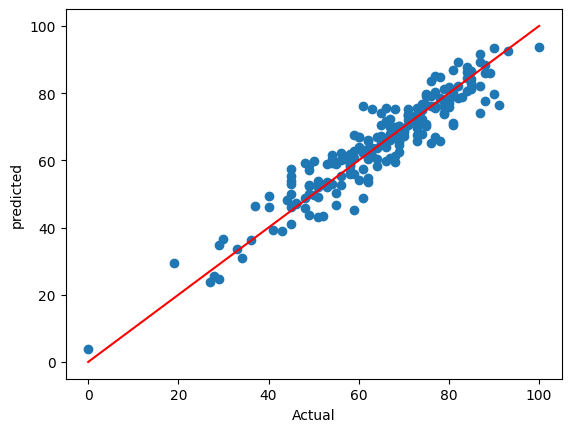

In [29]:
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
) 
plt.xlabel('Actual')
plt.ylabel('predicted')

In [30]:
pred_df = pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
